In [1]:
from gentropy.common.session import Session
from gentropy.dataset.study_index import StudyIndex
from gentropy.dataset.study_locus import StudyLocus
from gentropy.dataset.variant_index import VariantIndex
from gentropy.method.drug_enrichment_from_evid import chemblDrugEnrichment
from pyspark.sql import functions as f

Loading BokehJS ...

/Users/yt4/Projects/Gentropy-manuscript/.venv/lib/python3.11/site-packages/pyspark/sql/pandas/functions.py:407: UserWarning:

In Python 3.6+ and Spark 3.0+, it is preferred to specify type hints for pandas UDF instead of specifying pandas UDF type which will be deprecated in the future releases. See SPARK-28264 for more details.



In [2]:
session = Session(extended_spark_conf={"spark.driver.memory": "40G"})

Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
25/12/02 19:54:47 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
25/12/02 19:54:48 WARN Utils: Service 'SparkUI' could not bind on port 4040. Attempting port 4041.
25/12/02 19:54:48 WARN Utils: Service 'SparkUI' could not bind on port 4041. Attempting port 4042.


# Load data


In [3]:
path_to_release_folder = "../../../data/25.06/"

sl = StudyLocus.from_parquet(session, path_to_release_folder + "output/credible_set")
si = StudyIndex.from_parquet(session, path_to_release_folder + "output/study")

disease_index_path = path_to_release_folder + "output/disease/disease.parquet"
disease_index_orig = session.spark.read.parquet(disease_index_path)

platform_chembl_evidence_path = path_to_release_folder + "output/evidence/sourceId=chembl"
chembl_evidence = session.spark.read.parquet(platform_chembl_evidence_path)

efo_to_remove = chemblDrugEnrichment.selecting_all_decendands_based_on_efo_list(
    disease_index_orig=disease_index_orig,
    efo_ids="MONDO_0045024",
)

chembl_evidence.show(1)

l2g_full = session.spark.read.parquet("../../../data/intermediate_files/l2g_full_for_enrichment/")
l2g_full.count()

l2g_full.show(1)

g_p_s = session.spark.read.parquet("../../../data/intermediate_files/genes_therapeutic_areas")
g_p_s.count()

25/12/02 19:54:55 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.


+------------+---------------+-------------+-------------------+--------+----------+----+---------------------------+---------------------------+---------------------------------+--------------------------------+-----------------+-------------+----------+--------------------+--------+-------------+---------------------+--------------+-----------------+--------+----------------+---------------+----------+--------+-------------------+----------+----------------+--------------------+-------------------+-------------------------+-------------------------------------+-------------------------------------+--------------+----------+------------+-----------------+----------+----------------------------+-------------------+--------------+---------+--------------------------------+--------------------------------+--------------+--------------+--------+---------+----------+------------+-----------+--------------+-------------+----+------------------------+-----------------+-----------------------

8285

# Test run


In [4]:
import pandas as pd

all_enrich = []

for year in range(2025, 2026):
    evidence = chemblDrugEnrichment.to_disease_target_evidence(
        table_with_score=l2g_full.filter(f.col("year") <= year).drop("diseaseIds"),
        score_column="score",
        datasource_id="l2g",
        study_locus=sl,
        study_index=si,
        min_score=0.1,
    )

    enrich = chemblDrugEnrichment.drug_enrichemnt_from_evidence(
        evid=evidence,
        disease_index_orig=disease_index_orig,
        chembl_orig=chembl_evidence,
        indirect_assoc_score_thr=0.1,
        efo_ancestors_to_remove=["MONDO_0045024"],
    )
    enrich["datasource"] = str(year)
    enrich["drugsource"] = "full_chembl"

    all_enrich.append(enrich)

In [ ]:
pd.concat(all_enrich)

,clinicalPhase,odds_ratio,p_value,ci_low,ci_high,Relative success,ci_rs_low,ci_rs_high,rs_p_value,no_evid-low_clinphase,no_evid-high_clinphase,yes_evid-low_clinphase,yes_evid-high_clinphase,total_indirect_assoc,datasource,drugsource
0,2+,1.746148,1.154068e-06,1.375083,2.217346,1.076425,1.050129,1.103380,5.340474e-09,6087,30548,76,666,151704,2025,full_chembl
1,3+,2.060942,7.941172e-22,1.773924,2.394399,1.398926,1.321405,1.480995,8.135878e-31,20294,16341,279,463,151704,2025,full_chembl
2,4+,3.618578,3.534571e-49,3.093638,4.232591,2.764540,2.483639,3.077211,3.161170e-77,32313,4322,500,242,151704,2025,full_chembl


# Low-resolution binned gPS analysis


In [ ]:
import numpy as np
import pandas as pd

all_enrich = []

# Calculate quantiles for uniqueDiseases to create 5 bins
quantiles = np.array([1, 2, 5, 10, 148])

print(f"Bin boundaries (uniqueDiseases): {quantiles}")

Bin boundaries (uniqueDiseases): [  1   2   5  10 148]


In [ ]:
genes_to_remove = l2g_full.select("geneId").distinct().withColumnRenamed("geneId", "targetId").cache()
genes_to_remove.count()

8285

In [ ]:
chembl = chemblDrugEnrichment.process_chembl_evidence(chembl_evidence, efo_to_remove)
chembl_for_analysis = chembl.drop("maxClinicalPhase").withColumn("resourceScore", f.lit(1)).cache()
chembl_for_analysis.count()

37377

In [ ]:
chembl_bin = chembl_for_analysis.join(genes_to_remove, on="targetId", how="left_anti").cache()
chembl_bin.count()

18897

In [ ]:
enrich = chemblDrugEnrichment.drug_enrichemnt_from_evidence(
    evid=chembl_bin,
    disease_index_orig=disease_index_orig,
    chembl_orig=chembl_evidence,
    indirect_assoc_score_thr=0.1,
    efo_ancestors_to_remove=["MONDO_0045024"],
)
enrich

,clinicalPhase,odds_ratio,p_value,ci_low,ci_high,Relative success,ci_rs_low,ci_rs_high,rs_p_value,no_evid-low_clinphase,no_evid-high_clinphase,yes_evid-low_clinphase,yes_evid-high_clinphase,total_indirect_assoc
0,2+,0.993707,8.235175e-01,0.940863,1.049520,0.998960,0.990000,1.008001,8.208775e-01,3039,15441,3124,15773,63002
1,3+,0.965682,9.410039e-02,0.927109,1.005859,0.980964,0.959202,1.003219,9.311833e-02,10091,8389,10482,8415,63002
2,4+,0.740715,3.091163e-21,0.695957,0.788352,0.768267,0.727286,0.811557,4.272818e-21,15924,2556,16889,2008,63002


In [ ]:
enrich["datasource"] = "0"
enrich["bin_lower"] = 0
enrich["bin_upper"] = 1
enrich["bin_number"] = 0
enrich["n_genes_in_chembl"] = chembl_bin.select("targetId").distinct().count()
enrich["drugsource"] = "full_chembl"

all_enrich.append(enrich)

In [ ]:
for i, (lower, upper) in enumerate(zip(quantiles[:-1], quantiles[1:])):
    bin_name = f"bin_{i + 1}_{lower:.1f}_{upper:.1f}"
    print(f"Processing {bin_name}: uniqueDiseases >= {lower} and < {upper}")

    # Filter data based on uniqueDiseases bin
    if i == len(quantiles) - 2:  # Last bin includes upper boundary
        filtered_data = g_p_s.filter((f.col("uniqueDiseases") >= lower) & (f.col("uniqueDiseases") <= upper))
    else:
        filtered_data = g_p_s.filter((f.col("uniqueDiseases") >= lower) & (f.col("uniqueDiseases") < upper))

    genes_to_include = filtered_data.select("geneId").distinct().withColumnRenamed("geneId", "targetId")
    chembl_bin = chembl_for_analysis.join(genes_to_include, on="targetId", how="inner").cache()

    enrich = chemblDrugEnrichment.drug_enrichemnt_from_evidence(
        evid=chembl_bin,
        disease_index_orig=disease_index_orig,
        chembl_orig=chembl_evidence,
        indirect_assoc_score_thr=0.1,
        efo_ancestors_to_remove=["MONDO_0045024"],
    )

    enrich["datasource"] = bin_name
    enrich["n_genes_in_chembl"] = chembl_bin.select("targetId").distinct().count()
    enrich["bin_lower"] = lower
    enrich["bin_upper"] = upper
    enrich["bin_number"] = i + 1
    enrich["drugsource"] = "full_chembl"

    all_enrich.append(enrich)

Processing bin_1_1.0_2.0: uniqueDiseases >= 1 and < 2


Processing bin_2_2.0_5.0: uniqueDiseases >= 2 and < 5


Processing bin_3_5.0_10.0: uniqueDiseases >= 5 and < 10


Processing bin_4_10.0_148.0: uniqueDiseases >= 10 and < 148


In [ ]:
combined_enrich = pd.concat(all_enrich, ignore_index=True)
combined_enrich_4 = combined_enrich[combined_enrich["clinicalPhase"] == "4+"]
combined_enrich_4

,clinicalPhase,odds_ratio,p_value,ci_low,ci_high,Relative success,ci_rs_low,ci_rs_high,rs_p_value,no_evid-low_clinphase,no_evid-high_clinphase,yes_evid-low_clinphase,yes_evid-high_clinphase,total_indirect_assoc,datasource,bin_lower,bin_upper,bin_number,n_genes_in_chembl,drugsource
2,4+,0.740715,3.091163e-21,0.695957,0.788352,0.768267,0.727286,0.811557,4.272818e-21,15924,2556,16889,2008,63002,0,0,1,0,580,full_chembl
5,4+,1.151604,9.975172e-04,1.059906,1.251235,1.131077,1.052544,1.215470,7.941347e-04,27864,3789,4949,775,19317,bin_1_1.0_2.0,1,2,1,198,full_chembl
8,4+,1.300263,4.064631e-10,1.199608,1.409363,1.255955,1.172069,1.345845,1.034556e-10,27920,3717,4893,847,20072,bin_2_2.0_5.0,2,5,2,230,full_chembl
11,4+,1.177394,1.300784e-03,1.067809,1.298225,1.152805,1.059545,1.254273,9.536411e-04,29538,4037,3275,527,12948,bin_3_5.0_10.0,5,10,3,133,full_chembl
14,4+,1.046598,4.138522e-01,0.938609,1.167012,1.040698,0.946232,1.144594,4.112802e-01,30006,4157,2807,407,11450,bin_4_10.0_148.0,10,148,4,132,full_chembl


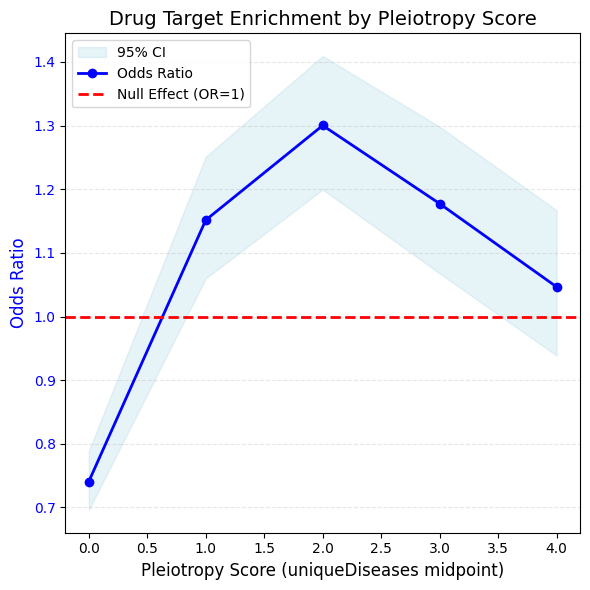

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

bin_lower = combined_enrich_4["bin_lower"]
bin_upper = combined_enrich_4["bin_upper"]
bin_number = combined_enrich_4["bin_number"]
odds_ratios = combined_enrich_4["odds_ratio"]
ci_low = combined_enrich_4["ci_low"]
ci_high = combined_enrich_4["ci_high"]
yes_evid_high = combined_enrich_4["yes_evid-high_clinphase"]

# Calculate bin midpoints for x-axis
bin_midpoints = (bin_lower + bin_upper) / 2

# Sort by bin_number for proper ordering
sorted_indices = np.argsort(bin_number)

# Sort all variables
bin_midpoints_sorted = bin_number.iloc[sorted_indices]
odds_ratios_sorted = odds_ratios.iloc[sorted_indices]
ci_low_sorted = ci_low.iloc[sorted_indices]
ci_high_sorted = ci_high.iloc[sorted_indices]
yes_evid_high_sorted = yes_evid_high.iloc[sorted_indices]

# Create the plot
fig, ax1 = plt.subplots(figsize=(6, 6))

# Plot odds ratios on left y-axis
ax1.fill_between(
    bin_midpoints_sorted,
    ci_low_sorted,
    ci_high_sorted,
    alpha=0.3,
    color="lightblue",
    label="95% CI",
)
ax1.plot(
    bin_midpoints_sorted,
    odds_ratios_sorted,
    "o-",
    color="blue",
    linewidth=2,
    markersize=6,
    label="Odds Ratio",
)
ax1.axhline(y=1, color="red", linestyle="--", linewidth=2, label="Null Effect (OR=1)")

# Customize axes
ax1.set_xlabel("Pleiotropy Score (uniqueDiseases midpoint)", fontsize=12)
ax1.set_ylabel("Odds Ratio", fontsize=12, color="blue")
ax1.tick_params(axis="y", labelcolor="blue")
ax1.grid(axis="y", linestyle="--", alpha=0.3)

# Remove the second y-axis section entirely:
# ax2 = ax1.twinx()
# ax2.plot(bin_midpoints_sorted, yes_evid_high_sorted, 's-', color='green',
#          linewidth=2, markersize=6, label="T-I pairs with approved drug")
# ax2.set_ylabel("T-I pairs with approved drug", fontsize=12, color='green')
# ax2.tick_params(axis='y', labelcolor='green')

plt.title("Drug Target Enrichment by Pleiotropy Score", fontsize=14)

# Use only the first legend
ax1.legend(loc="upper left", fontsize=10)

plt.tight_layout()
plt.show()

# Low-resolution binned gPS-adjusted analysis


In [ ]:
g_p_s.show(1)

+---------------+--------------+----------------------+------------+------------+------+--------------+----------------------+----------------------+-----------------------+-------------------+-----------------+---------------------------+----------------------+---------------------+---------------+-----------------------+---------------------------------+--------------------------+----------------------+----------------------------+--------------------+----------------------------------------+-------------+-------------------+------------------+--------------------+-------------------+-----------------------------+----------------------------------+----------------------------------+-------------+-----+------------+--------------+-------------+-------------+-------------+------------+-----------------+------------------+
|         geneId|uniqueDiseases|uniqueTherapeuticAreas|maxEQTLColoc|maxPQTLColoc|maxVEP|maxDistanceTSS|minEffectiveSampleSize|maxEffectiveSampleSize|earliestPublicati

In [ ]:
# (A) Plain NB: uniqueDiseases ~ maxEffectiveSampleSize
import numpy as np
import statsmodels.api as sm
from pyspark.sql import functions as F

# pull only the columns we need to the driver
pdf = g_p_s.select("geneId", "uniqueDiseases", "maxEffectiveSampleSize").toPandas()

# drop rows with missing values
# pdf = pdf.dropna(subset=["uniqueDiseases", "maxEffectiveSampleSize"])

# ensure numeric types
pdf["uniqueDiseases"] = pdf["uniqueDiseases"].astype(float)
pdf["maxEffectiveSampleSize"] = pdf["maxEffectiveSampleSize"].astype(float)

# design matrix with intercept
X = sm.add_constant(pdf["maxEffectiveSampleSize"])
y = pdf["uniqueDiseases"]

# fit Negative Binomial GLM
model = sm.GLM(y, X, family=sm.families.NegativeBinomial())
res = model.fit()

# compute response residuals (y - mu). Alternatives: res.resid_pearson, res.resid_deviance
pdf["nb_resid"] = res.resid_response

# push residuals back to Spark and join
spark_resid = session.spark.createDataFrame(pdf[["geneId", "nb_resid"]])
g_p_s = g_p_s.join(spark_resid, on="geneId", how="left")

/Users/yt4/Projects/Gentropy-manuscript/.venv/lib/python3.11/site-packages/statsmodels/genmod/families/family.py:1367: ValueWarning:

Negative binomial dispersion parameter alpha not set. Using default value alpha=1.0.



In [ ]:
g_p_s.show(1)

+---------------+--------------+----------------------+------------+------------+------+--------------+----------------------+----------------------+-----------------------+-------------------+-----------------+---------------------------+----------------------+---------------------+---------------+-----------------------+---------------------------------+--------------------------+----------------------+----------------------------+--------------------+----------------------------------------+-------------+-------------------+------------------+--------------------+-------------------+-----------------------------+----------------------------------+----------------------------------+-------------+-----+------------+--------------+-------------+-------------+-------------+------------+-----------------+------------------+------------------+
|         geneId|uniqueDiseases|uniqueTherapeuticAreas|maxEQTLColoc|maxPQTLColoc|maxVEP|maxDistanceTSS|minEffectiveSampleSize|maxEffectiveSampleSiz

In [ ]:
# collect to pandas and compute Spearman
import scipy.stats as stats

pdf = g_p_s.select("nb_resid", "uniqueDiseases").dropna().toPandas()

# ensure numeric
x = pd.to_numeric(pdf["nb_resid"], errors="coerce")
y = pd.to_numeric(pdf["uniqueDiseases"], errors="coerce")

rho, pval = stats.spearmanr(x, y)  # returns (rho, p-value)
print(f"Spearman rho = {rho:.4f}, p-value = {pval:.3g}, n = {len(x)}")

Spearman rho = 0.7070, p-value = 0, n = 8285


In [ ]:
from pyspark.sql import functions as f


def nb_resid_bins(gp_df, col="nb_resid", n_cutpoints=3, relative_error=0.01):
    """Return a list: [min, q1, q2, ..., q_k, max]
    where q_i are the evenly spaced quantiles (i/(k+1)).
    - gp_df: Spark DataFrame (g_p_s)
    - col: column name with residuals
    - n_cutpoints: number of quantile cut points to compute (k)
    - relative_error: passed to approxQuantile (0 for exact but slower)
    """
    # probabilities for k cutpoints: 1/(k+1), 2/(k+1), ..., k/(k+1)
    probs = [i / (n_cutpoints + 1) for i in range(1, n_cutpoints + 1)]
    # compute quantiles (approx) for the column
    cut_vals = gp_df.approxQuantile(col, probs, relative_error)  # returns list of values (len = k)
    # compute min and max
    mm = gp_df.agg(f.min(f.col(col)).alias("minv"), f.max(f.col(col)).alias("maxv")).first()
    minv, maxv = mm["minv"], mm["maxv"]
    # Compose final list and ensure it's sorted and unique (in case of ties)
    bins = [minv] + cut_vals + [maxv]
    # sort & unique to avoid duplicate cut points (optional)
    bins = sorted(dict.fromkeys(bins))
    return bins


# Example usage:
bins = nb_resid_bins(g_p_s, col="nb_resid", n_cutpoints=3, relative_error=0.001)
print("Bins:", bins)

Bins: [-15.540643187020759, -2.160922308386195, -1.55031809411143, 0.6383253024826145, 138.28707447451197]


In [ ]:
all_enrich = []
for i, (lower, upper) in enumerate(zip(bins[:-1], bins[1:])):
    bin_name = f"bin_{i + 1}_{lower:.1f}_{upper:.1f}"
    print(f"Processing {bin_name}: gPS_adj >= {lower} and < {upper}")
    print("N_genes:", g_p_s.filter((f.col("nb_resid") >= lower) & (f.col("nb_resid") < upper)).count())
    # Filter data based on uniqueDiseases bin
    if i == len(bins) - 2:  # Last bin includes upper boundary
        filtered_data = g_p_s.filter((f.col("nb_resid") >= lower) & (f.col("nb_resid") <= upper))
    else:
        filtered_data = g_p_s.filter((f.col("nb_resid") >= lower) & (f.col("nb_resid") < upper))

    genes_to_include = filtered_data.select("geneId").distinct().withColumnRenamed("geneId", "targetId")
    chembl_bin = chembl_for_analysis.join(genes_to_include, on="targetId", how="inner").cache()

    enrich = chemblDrugEnrichment.drug_enrichemnt_from_evidence(
        evid=chembl_bin,
        disease_index_orig=disease_index_orig,
        chembl_orig=chembl_evidence,
        indirect_assoc_score_thr=0.1,
        efo_ancestors_to_remove=["MONDO_0045024"],
    )

    enrich["datasource"] = bin_name
    enrich["n_genes_in_chembl"] = chembl_bin.select("targetId").distinct().count()
    enrich["bin_lower"] = lower
    enrich["bin_upper"] = upper
    enrich["bin_number"] = i + 1
    enrich["drugsource"] = "full_chembl"

    all_enrich.append(enrich)

Processing bin_1_-15.5_-2.2: gPS_adj >= -15.540643187020759 and < -2.160922308386195
N_genes: 2040


25/11/24 12:45:39 WARN DAGScheduler: Broadcasting large task binary with size 1021.7 KiB
25/11/24 12:45:41 WARN DAGScheduler: Broadcasting large task binary with size 1026.5 KiB
25/11/24 12:45:43 WARN DAGScheduler: Broadcasting large task binary with size 1026.7 KiB
25/11/24 12:45:45 WARN DAGScheduler: Broadcasting large task binary with size 1027.4 KiB
25/11/24 12:45:47 WARN DAGScheduler: Broadcasting large task binary with size 1027.5 KiB
25/11/24 12:45:49 WARN DAGScheduler: Broadcasting large task binary with size 1026.5 KiB
25/11/24 12:45:51 WARN DAGScheduler: Broadcasting large task binary with size 1026.7 KiB
25/11/24 12:45:53 WARN DAGScheduler: Broadcasting large task binary with size 1027.4 KiB
25/11/24 12:45:55 WARN DAGScheduler: Broadcasting large task binary with size 1027.5 KiB
25/11/24 12:45:58 WARN DAGScheduler: Broadcasting large task binary with size 1026.5 KiB
25/11/24 12:46:00 WARN DAGScheduler: Broadcasting large task binary with size 1026.7 KiB
25/11/24 12:46:02 WAR

Processing bin_2_-2.2_-1.6: gPS_adj >= -2.160922308386195 and < -1.55031809411143
N_genes: 2096


25/11/24 12:46:16 WARN DAGScheduler: Broadcasting large task binary with size 1021.7 KiB
25/11/24 12:46:16 WARN DAGScheduler: Broadcasting large task binary with size 1026.6 KiB
25/11/24 12:46:18 WARN DAGScheduler: Broadcasting large task binary with size 1026.7 KiB
25/11/24 12:46:19 WARN DAGScheduler: Broadcasting large task binary with size 1027.4 KiB
25/11/24 12:46:20 WARN DAGScheduler: Broadcasting large task binary with size 1027.5 KiB
25/11/24 12:46:22 WARN DAGScheduler: Broadcasting large task binary with size 1026.6 KiB
25/11/24 12:46:23 WARN DAGScheduler: Broadcasting large task binary with size 1026.7 KiB
25/11/24 12:46:25 WARN DAGScheduler: Broadcasting large task binary with size 1027.4 KiB
25/11/24 12:46:27 WARN DAGScheduler: Broadcasting large task binary with size 1027.5 KiB
25/11/24 12:46:30 WARN DAGScheduler: Broadcasting large task binary with size 1026.6 KiB
25/11/24 12:46:32 WARN DAGScheduler: Broadcasting large task binary with size 1026.7 KiB
25/11/24 12:46:34 WAR

Processing bin_3_-1.6_0.6: gPS_adj >= -1.55031809411143 and < 0.6383253024826145
N_genes: 2067


25/11/24 12:46:52 WARN DAGScheduler: Broadcasting large task binary with size 1021.7 KiB
25/11/24 12:46:54 WARN DAGScheduler: Broadcasting large task binary with size 1026.6 KiB
25/11/24 12:46:56 WARN DAGScheduler: Broadcasting large task binary with size 1026.7 KiB
25/11/24 12:46:58 WARN DAGScheduler: Broadcasting large task binary with size 1027.4 KiB
25/11/24 12:47:00 WARN DAGScheduler: Broadcasting large task binary with size 1027.5 KiB
25/11/24 12:47:02 WARN DAGScheduler: Broadcasting large task binary with size 1026.6 KiB
25/11/24 12:47:04 WARN DAGScheduler: Broadcasting large task binary with size 1026.7 KiB
25/11/24 12:47:06 WARN DAGScheduler: Broadcasting large task binary with size 1027.4 KiB
25/11/24 12:47:08 WARN DAGScheduler: Broadcasting large task binary with size 1027.5 KiB
25/11/24 12:47:11 WARN DAGScheduler: Broadcasting large task binary with size 1026.6 KiB
25/11/24 12:47:13 WARN DAGScheduler: Broadcasting large task binary with size 1026.7 KiB
25/11/24 12:47:15 WAR

Processing bin_4_0.6_138.3: gPS_adj >= 0.6383253024826145 and < 138.28707447451197
N_genes: 2081


25/11/24 12:47:34 WARN DAGScheduler: Broadcasting large task binary with size 1021.8 KiB
25/11/24 12:47:36 WARN DAGScheduler: Broadcasting large task binary with size 1026.6 KiB
25/11/24 12:47:38 WARN DAGScheduler: Broadcasting large task binary with size 1026.8 KiB
25/11/24 12:47:40 WARN DAGScheduler: Broadcasting large task binary with size 1027.4 KiB
25/11/24 12:47:43 WARN DAGScheduler: Broadcasting large task binary with size 1027.5 KiB
25/11/24 12:47:45 WARN DAGScheduler: Broadcasting large task binary with size 1026.6 KiB
25/11/24 12:47:47 WARN DAGScheduler: Broadcasting large task binary with size 1026.8 KiB
25/11/24 12:47:49 WARN DAGScheduler: Broadcasting large task binary with size 1027.4 KiB
25/11/24 12:47:51 WARN DAGScheduler: Broadcasting large task binary with size 1027.5 KiB
25/11/24 12:47:53 WARN DAGScheduler: Broadcasting large task binary with size 1026.6 KiB
25/11/24 12:47:55 WARN DAGScheduler: Broadcasting large task binary with size 1026.8 KiB
25/11/24 12:47:57 WAR

In [ ]:
combined_enrich = pd.concat(all_enrich, ignore_index=True)
combined_enrich_4 = combined_enrich[combined_enrich["clinicalPhase"] == "4+"]
combined_enrich_4

,clinicalPhase,odds_ratio,p_value,ci_low,ci_high,Relative success,ci_rs_low,ci_rs_high,rs_p_value,no_evid-low_clinphase,no_evid-high_clinphase,yes_evid-low_clinphase,yes_evid-high_clinphase,total_indirect_assoc,datasource,n_genes_in_chembl,bin_lower,bin_upper,bin_number,drugsource
2,4+,1.172330,9.549049e-04,1.068134,1.286690,1.148564,1.059775,1.244792,7.399716e-04,29131,3975,3682,589,14856,bin_1_-15.5_-2.2,154,-15.540643,-2.160922,1,full_chembl
5,4+,1.030772,5.745741e-01,0.929129,1.143536,1.026924,0.937725,1.124607,5.665956e-01,29651,4112,3162,452,12238,bin_2_-2.2_-1.6,129,-2.160922,-1.550318,2,full_chembl
8,4+,1.225234,4.711566e-05,1.113302,1.348420,1.193066,1.098715,1.295519,2.672635e-05,29488,4010,3325,554,13777,bin_3_-1.6_0.6,158,-1.550318,0.638325,3,full_chembl
11,4+,1.254035,1.176915e-08,1.161519,1.353918,1.217684,1.139822,1.300866,5.162033e-09,27058,3603,5755,961,22916,bin_4_0.6_138.3,252,0.638325,138.287074,4,full_chembl


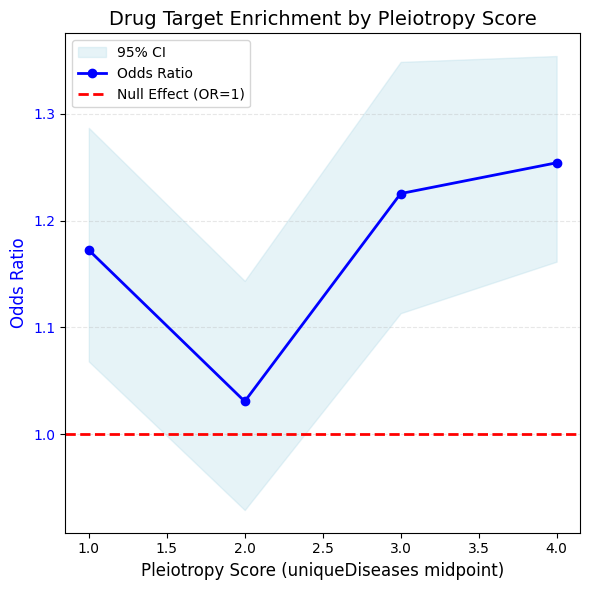

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

bin_lower = combined_enrich_4["bin_lower"]
bin_upper = combined_enrich_4["bin_upper"]
bin_number = combined_enrich_4["bin_number"]
odds_ratios = combined_enrich_4["odds_ratio"]
ci_low = combined_enrich_4["ci_low"]
ci_high = combined_enrich_4["ci_high"]
yes_evid_high = combined_enrich_4["yes_evid-high_clinphase"]

# Calculate bin midpoints for x-axis
bin_midpoints = (bin_lower + bin_upper) / 2

# Sort by bin_number for proper ordering
sorted_indices = np.argsort(bin_number)

# Sort all variables
bin_midpoints_sorted = bin_number.iloc[sorted_indices]
odds_ratios_sorted = odds_ratios.iloc[sorted_indices]
ci_low_sorted = ci_low.iloc[sorted_indices]
ci_high_sorted = ci_high.iloc[sorted_indices]
yes_evid_high_sorted = yes_evid_high.iloc[sorted_indices]

# Create the plot
fig, ax1 = plt.subplots(figsize=(6, 6))

# Plot odds ratios on left y-axis
ax1.fill_between(
    bin_midpoints_sorted,
    ci_low_sorted,
    ci_high_sorted,
    alpha=0.3,
    color="lightblue",
    label="95% CI",
)
ax1.plot(
    bin_midpoints_sorted,
    odds_ratios_sorted,
    "o-",
    color="blue",
    linewidth=2,
    markersize=6,
    label="Odds Ratio",
)
ax1.axhline(y=1, color="red", linestyle="--", linewidth=2, label="Null Effect (OR=1)")

# Customize axes
ax1.set_xlabel("Pleiotropy Score (uniqueDiseases midpoint)", fontsize=12)
ax1.set_ylabel("Odds Ratio", fontsize=12, color="blue")
ax1.tick_params(axis="y", labelcolor="blue")
ax1.grid(axis="y", linestyle="--", alpha=0.3)

# Remove the second y-axis section entirely:
# ax2 = ax1.twinx()
# ax2.plot(bin_midpoints_sorted, yes_evid_high_sorted, 's-', color='green',
#          linewidth=2, markersize=6, label="T-I pairs with approved drug")
# ax2.set_ylabel("T-I pairs with approved drug", fontsize=12, color='green')
# ax2.tick_params(axis='y', labelcolor='green')

plt.title("Drug Target Enrichment by Pleiotropy Score", fontsize=14)

# Use only the first legend
ax1.legend(loc="upper left", fontsize=10)

plt.tight_layout()
plt.show()

# High resolution enrichment by gPS bins


In [5]:
import numpy as np
import pandas as pd

# Calculate quantiles for uniqueDiseases to create 5 bins
quantiles = np.array([1, 2, 5, 10, 148])

print(f"Bin boundaries (uniqueDiseases): {quantiles}")

Bin boundaries (uniqueDiseases): [  1   2   5  10 148]


In [6]:
all_enrich = []
for i, (lower, upper) in enumerate(zip(quantiles[:-1], quantiles[1:])):
    print(f"Processing: gPS >= {lower} and < {upper}")
    print("N_genes:", g_p_s.filter((f.col("uniqueDiseases") >= lower) & (f.col("uniqueDiseases") < upper)).count())
    # Filter data based on uniqueDiseases bin
    if i == len(quantiles) - 2:  # Last bin includes upper boundary
        filtered_data = g_p_s.filter((f.col("uniqueDiseases") >= lower) & (f.col("uniqueDiseases") <= upper))
        bin_name = f"[{lower}:{upper}], {filtered_data.count()}"
    else:
        filtered_data = g_p_s.filter((f.col("uniqueDiseases") >= lower) & (f.col("uniqueDiseases") < upper))
        bin_name = f"[{lower}:{upper}), {filtered_data.count()}"

    genes_to_include = filtered_data.select("geneId").distinct()

    evidence = chemblDrugEnrichment.to_disease_target_evidence(
        table_with_score=l2g_full.join(genes_to_include, on="geneId", how="inner").drop("diseaseIds"),
        score_column="score",
        datasource_id="l2g",
        study_locus=sl,
        study_index=si,
        min_score=0.1,
    )

    enrich = chemblDrugEnrichment.drug_enrichemnt_from_evidence(
        evid=evidence,
        disease_index_orig=disease_index_orig,
        chembl_orig=chembl_evidence,
        indirect_assoc_score_thr=0.1,
        efo_ancestors_to_remove=["MONDO_0045024"],
    )

    enrich["datasource"] = bin_name
    enrich["n_genes_in_bin"] = genes_to_include.count()
    enrich["bin_lower"] = lower
    enrich["bin_upper"] = upper
    enrich["bin_number"] = i + 1
    enrich["drugsource"] = "full_chembl"

    all_enrich.append(enrich)

Processing: gPS >= 1 and < 2
N_genes: 2971


Processing: gPS >= 2 and < 5
N_genes: 3022


Processing: gPS >= 5 and < 10
N_genes: 1388


Processing: gPS >= 10 and < 148
N_genes: 903


In [7]:
combined_enrich = pd.concat(all_enrich, ignore_index=True)
combined_enrich_4 = combined_enrich[combined_enrich["clinicalPhase"] == "4+"]
combined_enrich_4

,clinicalPhase,odds_ratio,p_value,ci_low,ci_high,Relative success,ci_rs_low,ci_rs_high,rs_p_value,no_evid-low_clinphase,no_evid-high_clinphase,yes_evid-low_clinphase,yes_evid-high_clinphase,total_indirect_assoc,datasource,n_genes_in_bin,bin_lower,bin_upper,bin_number,drugsource
2,4+,4.326837,6.698908e-06,2.410068,7.768045,3.079273,2.134974,4.441235,1.754784e-09,32783,4546,30,18,19044,"[1:2), 2971",2971,1,2,1,full_chembl
5,4+,4.868867,1.180048e-16,3.455051,6.861219,3.315672,2.697623,4.075321,4.758090e-30,32731,4509,82,55,41590,"[2:5), 3022",3022,2,5,2,full_chembl
8,4+,3.748020,3.360308e-15,2.774007,5.064030,2.812830,2.304456,3.433354,2.746662e-24,32687,4499,126,65,37935,"[5:10), 1388",1388,5,10,3,full_chembl
11,4+,2.897087,9.038398e-17,2.303435,3.643737,2.358024,1.999506,2.780825,2.095593e-24,32551,4460,262,104,53135,"[10:148], 904",904,10,148,4,full_chembl


In [ ]:
combined_enrich_3 = combined_enrich[combined_enrich["clinicalPhase"] == "3+"]
combined_enrich_3

,clinicalPhase,odds_ratio,p_value,ci_low,ci_high,Relative success,ci_rs_low,ci_rs_high,rs_p_value,no_evid-low_clinphase,no_evid-high_clinphase,yes_evid-low_clinphase,yes_evid-high_clinphase,total_indirect_assoc,datasource,n_genes_in_bin,bin_lower,bin_upper,bin_number,drugsource
1,3+,2.042347,1.928827e-02,1.138128,3.664950,1.390880,1.116853,1.732142,3.206894e-03,20555,16774,18,30,19044,"[1:2), 2971",2971,1,2,1,full_chembl
4,3+,2.511271,2.492377e-07,1.757088,3.589165,1.496403,1.330308,1.683235,1.884834e-11,20528,16712,45,92,41590,"[2:5), 3022",3022,2,5,2,full_chembl
7,3+,2.173208,1.662192e-07,1.616499,2.921643,1.423829,1.279028,1.585023,1.064270e-10,20504,16682,69,122,37935,"[5:10), 1388",1388,5,10,3,full_chembl
10,3+,1.834825,1.270717e-08,1.487299,2.263554,1.335299,1.226862,1.453319,2.207484e-11,20426,16585,147,219,53135,"[10:148], 904",904,10,148,4,full_chembl


25/11/26 16:41:09 WARN HeartbeatReceiver: Removing executor driver with no recent heartbeats: 433805 ms exceeds timeout 120000 ms
25/11/26 16:41:09 WARN SparkContext: Killing executors is not supported by current scheduler.
25/11/26 16:41:13 WARN Executor: Issue communicating with driver in heartbeater
org.apache.spark.SparkException: Exception thrown in awaitResult: 
	at org.apache.spark.util.SparkThreadUtils$.awaitResult(SparkThreadUtils.scala:56)
	at org.apache.spark.util.ThreadUtils$.awaitResult(ThreadUtils.scala:310)
	at org.apache.spark.rpc.RpcTimeout.awaitResult(RpcTimeout.scala:75)
	at org.apache.spark.rpc.RpcEndpointRef.askSync(RpcEndpointRef.scala:101)
	at org.apache.spark.rpc.RpcEndpointRef.askSync(RpcEndpointRef.scala:85)
	at org.apache.spark.storage.BlockManagerMaster.registerBlockManager(BlockManagerMaster.scala:80)
	at org.apache.spark.storage.BlockManager.reregister(BlockManager.scala:642)
	at org.apache.spark.executor.Executor.reportHeartBeat(Executor.scala:1223)
	at o

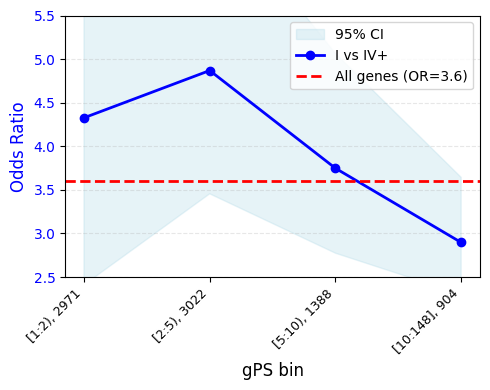

In [104]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

bin_lower = combined_enrich_4["bin_lower"]
bin_upper = combined_enrich_4["bin_upper"]
bin_number = combined_enrich_4["bin_number"]
odds_ratios = combined_enrich_4["odds_ratio"]
ci_low = combined_enrich_4["ci_low"]
ci_high = combined_enrich_4["ci_high"]
yes_evid_high = combined_enrich_4["yes_evid-high_clinphase"]
datasource = combined_enrich_4["datasource"].astype(str)  # ensure string labels

# Calculate bin midpoints for x-axis
bin_midpoints = (bin_lower + bin_upper) / 2

# Sort by bin_number for proper ordering
sorted_indices = np.argsort(bin_number)

# Sort all variables
bin_midpoints_sorted = bin_number.iloc[sorted_indices]
odds_ratios_sorted = odds_ratios.iloc[sorted_indices]
ci_low_sorted = ci_low.iloc[sorted_indices]
ci_high_sorted = ci_high.iloc[sorted_indices]
yes_evid_high_sorted = yes_evid_high.iloc[sorted_indices]
datasource_sorted = datasource.iloc[sorted_indices]

# Create the plot
fig, ax1 = plt.subplots(figsize=(5, 4))

# Plot odds ratios on left y-axis
ax1.fill_between(
    bin_midpoints_sorted,
    ci_low_sorted,
    ci_high_sorted,
    alpha=0.3,
    color="lightblue",
    label="95% CI",
)
ax1.plot(
    bin_midpoints_sorted,
    odds_ratios_sorted,
    "o-",
    color="blue",
    linewidth=2,
    markersize=6,
    label="I vs IV+",
)
ax1.axhline(y=3.6, color="red", linestyle="--", linewidth=2, label="All genes (OR=3.6)")

# Customize axes
ax1.set_xlabel("gPS bin", fontsize=12)
ax1.set_ylabel("Odds Ratio", fontsize=12, color="blue")
ax1.tick_params(axis="y", labelcolor="blue")
ax1.grid(axis="y", linestyle="--", alpha=0.3)

# Remove the second y-axis section entirely:
# ax2 = ax1.twinx()
# ax2.plot(bin_midpoints_sorted, yes_evid_high_sorted, 's-', color='green',
#          linewidth=2, markersize=6, label="T-I pairs with approved drug")
# ax2.set_ylabel("T-I pairs with approved drug", fontsize=12, color='green')
# ax2.tick_params(axis='y', labelcolor='green')

# plt.title("Drug Target Enrichment by Pleiotropy Score", fontsize=14)

# Use only the first legend
ax1.legend(loc="upper right", fontsize=10)

ax1.set_xticks(bin_midpoints_sorted)
ax1.set_xticklabels(datasource_sorted, rotation=45, ha="right", fontsize=9)
ax1.set_ylim(2.5, 5.5)

plt.tight_layout()
plt.show()

# The best category


In [ ]:
g_p_s.show(1)

+---------------+--------------+----------------------+------------+------------+------+--------------+----------------------+----------------------+-----------------------+-------------------+-----------------+---------------------------+----------------------+---------------------+---------------+-----------------------+---------------------------------+--------------------------+----------------------+----------------------------+--------------------+----------------------------------------+-------------+-------------------+------------------+--------------------+-------------------+-----------------------------+----------------------------------+----------------------------------+-------------+-----+------------+--------------+-------------+-------------+-------------+------------+-----------------+------------------+
|         geneId|uniqueDiseases|uniqueTherapeuticAreas|maxEQTLColoc|maxPQTLColoc|maxVEP|maxDistanceTSS|minEffectiveSampleSize|maxEffectiveSampleSize|earliestPublicati

In [4]:
l2g_full.show(1)

+--------------------+--------------------+---------------+-----------------+----------+----------+---+-----------+--------------------+--------------+----+------+---------------+----------+--------------+----+------------------+
|        studyLocusId|             studyId|         geneId|            score|eQTL_coloc|pQTL_coloc|VEP|distanceTSS|                 maf|     variantId|year|is_nfe|     diseaseIds|nfe_common|non_nfe_common|rare|           absBeta|
+--------------------+--------------------+---------------+-----------------+----------+----------+---+-----------+--------------------+--------------+----+------+---------------+----------+--------------+----+------------------+
|cd9dd38e1f85a069d...|FINNGEN_R12_H7_IR...|ENSG00000152954|0.344258189201355|         0|         0|  0|          1|0.029878971255673223|6_23867964_T_C|2024|     0|[MONDO_0004773]|         0|             1|   0|0.4207366138701276|
+--------------------+--------------------+---------------+-----------------+---

In [26]:
filtered_data = (
    g_p_s.filter(f.col("uniqueTherapeuticAreas") < 6)
    .filter(f.col("uniqueTherapeuticAreas") > 1)
    .select("geneId")
    .distinct()
)

evidence = chemblDrugEnrichment.to_disease_target_evidence(
    table_with_score=l2g_full.filter(f.col("VEP") == 1)
    .join(filtered_data, on="geneId", how="inner")
    .drop("diseaseIds"),
    score_column="score",
    datasource_id="l2g",
    study_locus=sl,
    study_index=si,
    min_score=0.1,
)

enrich = chemblDrugEnrichment.drug_enrichemnt_from_evidence(
    evid=evidence,
    disease_index_orig=disease_index_orig,
    chembl_orig=chembl_evidence,
    indirect_assoc_score_thr=0.1,
    efo_ancestors_to_remove=["MONDO_0045024"],
)

In [27]:
evidence.select("targetId", "diseaseId").distinct().count()

2734

In [28]:
evidence.select("targetId").distinct().count()

943

In [29]:
enrich

,clinicalPhase,odds_ratio,p_value,ci_low,ci_high,Relative success,ci_rs_low,ci_rs_high,rs_p_value,no_evid-low_clinphase,no_evid-high_clinphase,yes_evid-low_clinphase,yes_evid-high_clinphase,total_indirect_assoc
0,2+,5.540636,2.413890e-04,1.750932,17.532742,1.156574,1.111260,1.203735,9.789271e-13,6160,31130,3,84,12121
1,3+,5.897585,7.299695e-13,3.379999,10.290391,1.844411,1.674626,2.031410,1.925004e-35,20558,16732,15,72,12121
2,4+,10.288962,8.072448e-25,6.707865,15.781881,4.843708,4.051253,5.791173,4.052576e-67,32777,4513,36,51,12121


# The worst category


In [40]:
filtered_data = g_p_s.filter(f.col("uniqueTherapeuticAreas") >= 6).select("geneId").distinct()

evidence = chemblDrugEnrichment.to_disease_target_evidence(
    table_with_score=l2g_full.filter(f.col("VEP") == 0)
    .join(filtered_data, on="geneId", how="inner")
    .drop("diseaseIds"),
    score_column="score",
    datasource_id="l2g",
    study_locus=sl,
    study_index=si,
    min_score=0.1,
)

enrich = chemblDrugEnrichment.drug_enrichemnt_from_evidence(
    evid=evidence,
    disease_index_orig=disease_index_orig,
    chembl_orig=chembl_evidence,
    indirect_assoc_score_thr=0.1,
    efo_ancestors_to_remove=["MONDO_0045024"],
)

25/12/02 20:51:01 WARN CacheManager: Asked to cache already cached data.
25/12/02 20:51:02 WARN CacheManager: Asked to cache already cached data.


In [41]:
enrich

,clinicalPhase,odds_ratio,p_value,ci_low,ci_high,Relative success,ci_rs_low,ci_rs_high,rs_p_value,no_evid-low_clinphase,no_evid-high_clinphase,yes_evid-low_clinphase,yes_evid-high_clinphase,total_indirect_assoc
0,2+,1.583737,2.109498e-02,1.068183,2.348119,1.064860,1.019137,1.112633,5.006771e-03,6135,30990,28,224,41461
1,3+,1.777961,7.630919e-06,1.381927,2.287490,1.317976,1.188657,1.461364,1.605686e-07,20470,16655,103,149,41461
2,4+,2.963446,9.751044e-13,2.253272,3.897449,2.394670,1.969877,2.911068,1.869450e-18,32634,4491,179,73,41461
